# CS 425/525 Bioinformatics Algorithms Final Project: The prediction of DNA accessibility on Arabidopsis genomes and the affects of transfer learning
## By: Paulo McKone and Brendan Dellos

This notebook is a collection of our findings throughout our process for the first part we tested how a 3 layer CNN would compare on a regression problem vs a LSTM model on a regression problem. For the second part we took the best working model based on the pearson r correlation. We would then save that trained best working model and put it up against an untrained multi layer model on a dataset based more on classification trying to find enchacners activity in Arabidopsis. While the first dataset was a regression problem on predicting read coverage on the Arabidopsis.

## Load Dataset

>Note For time sake we didnt train anymore of our models within the actual notebook all of our code is within the supplying directories in respect to what part the model is in for example the regression problem code will be in the part 1 directory while the transfer learning classification problem will be in the part 2 directory. As well is all of the loading of the actual data is in there respective directories



## Setup

We begin by adding the part1 and part2 directories to the Python path so the notebook 
can import from our supporting code files. We also define paths to the saved CNN and LSTM 
models from Part 1, and set the device to GPU if available.

In [36]:
import sys
import os

sys.path.append(os.path.join(os.path.expanduser('~'), 'Genome-Accessibility-Project', 'part1'))
sys.path.append(os.path.join(os.path.expanduser('~'), 'Genome-Accessibility-Project', 'part2'))
path1CNN       = os.path.join(os.path.expanduser('~'), 'Genome-Accessibility-Project', 'results', 'model.pth')
path1LSTM      = os.path.join(os.path.expanduser('~'), 'Genome-Accessibility-Project', 'results', 'lstm_model.pth')

In [37]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from CNNReadCoverage import load_modelCNN, evaluate, CoverageDataset, CNNMultipleLayers
from DataProcess import load_windows
from LSTMReadCoverage import CoverageLSTM
from CNNUntrained import load_model, evaluate, get_dataloaders, get_loss_fn
from LoadData import load_processed


In [38]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Part 1  Model Training and result comparisons

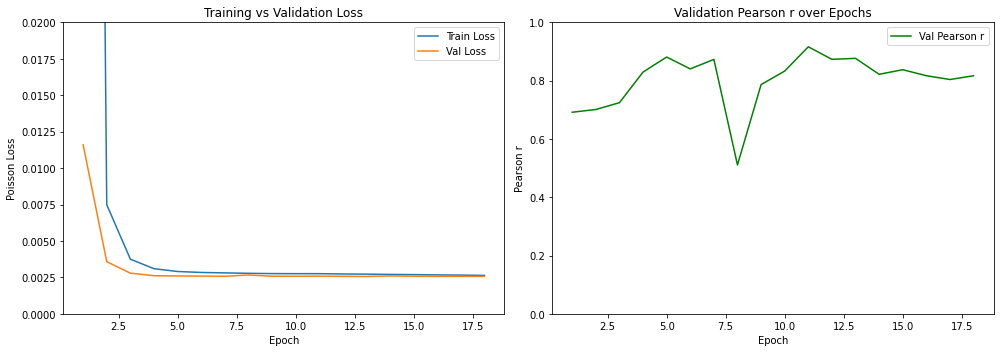

In [39]:
checkpoint = torch.load(path1CNN, map_location=device)

model      = CNNMultipleLayers(num_kernels=32, kernel_size=12, window_size=200).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

train_losses = checkpoint['train_losses']
val_losses   = checkpoint['val_losses']
val_pearsons = checkpoint.get('val_pearsons', [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
ax1.plot(range(1, len(val_losses)   + 1), val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Poisson Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_ylim(0, 0.02)  
ax1.legend()


ax2.plot(range(1, len(val_pearsons) + 1), val_pearsons, label='Val Pearson r', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Pearson r')
ax2.set_title('Validation Pearson r over Epochs')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

### CNN Results
The CNN model converges fast with training and validation loss dropping after the first couple epochs and starts to be stable at around 0.0025. The pearson r climbs constantly and remains relatively steady until at around 8 epochs when it jumps down to 0.5 but eveuntally becomes stable at 0.85. What this probably means is that the model is learning the patterns of the coverage data while the additional epochs aren't helping the model learn any new information. The random jump down could be some sort of noise that model came across during training.


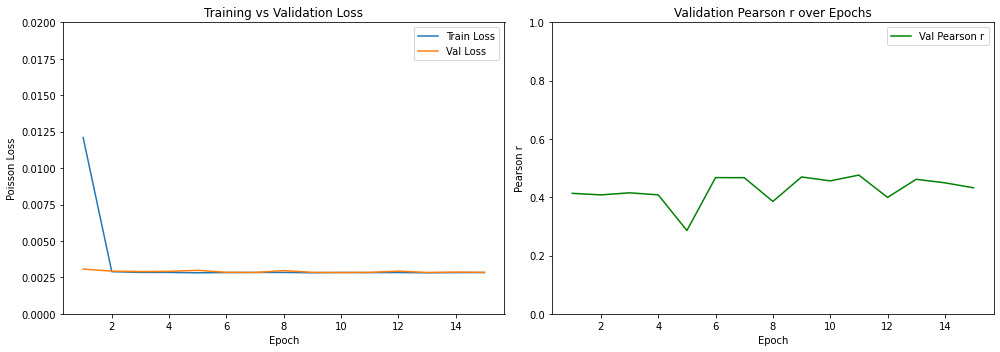

In [40]:

checkpoint   = torch.load(path1LSTM, map_location=device)
model        = CoverageLSTM(input_dim=1, hidden_dim=64, layer_dim=2, output_dim=1).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

train_losses = checkpoint['train_losses']
val_losses   = checkpoint['val_losses']
val_pearsons = checkpoint.get('val_pearsons', [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
ax1.plot(range(1, len(val_losses)   + 1), val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Poisson Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_ylim(0, 0.02)  
ax1.legend()

# Pearson r plot
ax2.plot(range(1, len(val_pearsons) + 1), val_pearsons, label='Val Pearson r', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Pearson r')
ax2.set_title('Validation Pearson r over Epochs')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

### LSTM Results
The LSTM model does the same same type of converging quickly in the terms of its loss values while val loss doesn't move at all the loss becomes stable at 0.0025 same as the cnn. While the Pearson r stays low throughout the entire training and is stable at 0.42 with high variance throughout training. The plateau at the low value of r is showing that the LSTM is struggling to learn coverage patterns it is converging to a poor solution. The high variance is probably due to LSTm being sensitive to how it processes the coverage data.

### Comparison LSTM vs CNN

The CNN heavily outperform the LSTM with the CNN having an overall pearson r at around 0.84 while the LSTM was stuck on values of pearson 0.42. Convoluting layers are better suited for capturing local patterns in the coverage data while LSTMs are designed for learning long term types of dependencies like language processing and recognition of speech which is unrelated to this which is why the CNN heavily outpreformed the LSTM.

## Part 2 Model Comparsion between best Tranfer learning and Untrained Basset CNN 

In [41]:
sys.path.append(os.path.abspath('part2'))
BASE_DIR   = os.path.abspath('..')
OUTPUT_DIR = os.path.join(BASE_DIR, 'results')
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [42]:
X_train, y_train, X_val, y_val, X_test, y_test = load_processed()
train_loader, val_loader, test_loader = get_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)
model, train_losses, val_losses, val_auprcs = load_model()

Train: 38700 | Val: 3572 | Test: 3442


In [43]:
loss_fn = get_loss_fn(y_train)
evaluate(model, test_loader, loss_fn, name='Test')


--- Test Evaluation ---
Loss  : 0.405309
AUPRC : 0.8625


(0.40530899525792513, 0.8625059951134101)

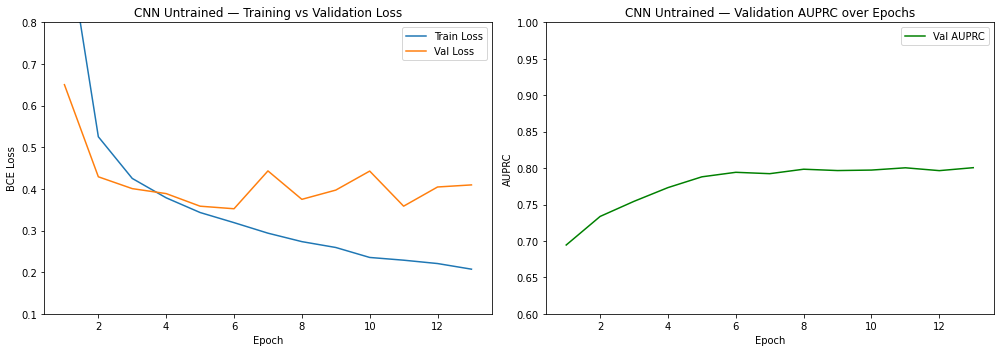

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
ax1.plot(range(1, len(val_losses)   + 1), val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('CNN Untrained — Training vs Validation Loss')
ax1.set_ylim(0.1, 0.8)  
ax1.legend()

ax2.plot(range(1, len(val_auprcs) + 1), val_auprcs, label='Val AUPRC', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUPRC')
ax2.set_title('CNN Untrained — Validation AUPRC over Epochs')
ax2.set_ylim(0.6, 1.0)  
ax2.legend()

plt.tight_layout()
plt.show()

In [45]:
from TransferCNN import TransferCNN, evaluate_transfer

transfer_model, transfer_train_losses, transfer_val_losses, transfer_val_auprcs = load_transfer_model()

In [46]:
loss_fn = get_loss_fn(y_train)
_,_,_,_,_ = evaluate_transfer(transfer_model, test_loader, loss_fn, device, name='Transfer Test')


--- Transfer Test Evaluation ---
BCE loss : 1.149765
AUPRC    : 0.2060
Accuracy : 0.6772


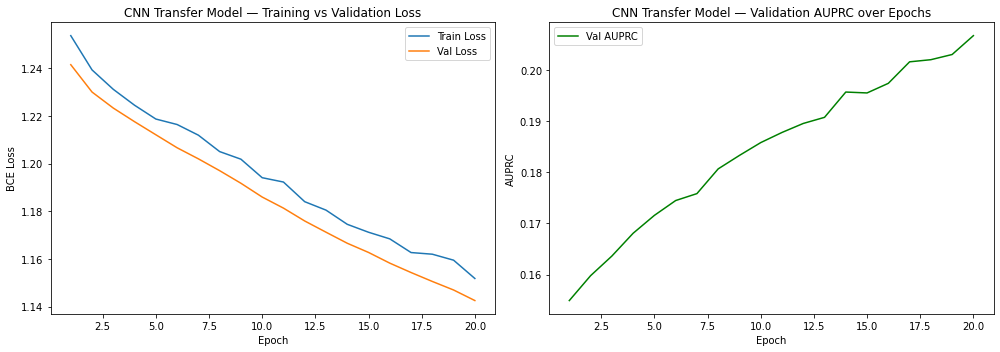

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(transfer_train_losses) + 1), transfer_train_losses, label='Train Loss')
ax1.plot(range(1, len(transfer_val_losses)   + 1), transfer_val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('CNN Transfer Model — Training vs Validation Loss')
ax1.legend()

ax2.plot(range(1, len(transfer_val_auprcs) + 1), transfer_val_auprcs, label='Val AUPRC', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUPRC')
ax2.set_title('CNN Transfer Model — Validation AUPRC over Epochs')
ax2.legend()

plt.tight_layout()
plt.show()